In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Period & Domain

In [4]:
iyear=1981
fyear=2015
dom='HMA'
latS,latN,lonW,lonE = coord_domain(dom)
models = ['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2', 'ERA5']

# Elevation datasets

In [5]:
#===================== APHRO ==========================

ds1_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
ds1_SH=ds1_SH_raw.rename({'latitude':'lat','longitude':'lon'})
ds1_SH=reversing_lat(ds1_SH)
field1_SH=field_dom(ds1_SH,dom)

#===================== GPCP ===========================

ds2_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field2_SH=field_dom(ds2_SH,dom)

#===================== CRU ============================

ds3_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_cru_hma_grid.nc')['elevation']
ds3_SH=reversing_lat(ds3_SH_raw)
field3_SH=field_dom(ds3_SH,dom)

#===================== CHIRPS =========================

ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
ds4_SH=ds4_SH.rename({'latitude':'lat','longitude':'lon'})
ds4_SH=reversing_lat(ds4_SH)
field4_SH=field_dom(ds4_SH,dom)

#===================== HARv2 ==========================

def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

ds5_grM= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_d10km_static_hgt.nc')
ds5_SH=ds5_grM['hgt'][0,:,:]
field5_SH=xy_sel_dom(ds5_SH,latS,latN,lonW,lonE)

#===================== ERA5 ===========================

ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
ds6_SH=ds6_SH.rename({'latitude':'lat','longitude':'lon'})
field6_SH=field_dom(ds6_SH,dom)

#======================================================

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}


time
west_east
south_north
lon
lat


# Seasonal Mean datasets

In [6]:
seasons = ['DJFM', 'AM', 'JJAS', 'ON'] 

tp_dict = {}

for model in models:
    tp_dict[model] = {}
    for season in seasons:
        path = f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc'
        tp_dict[model][season] = xr.open_dataset(path)['tp']

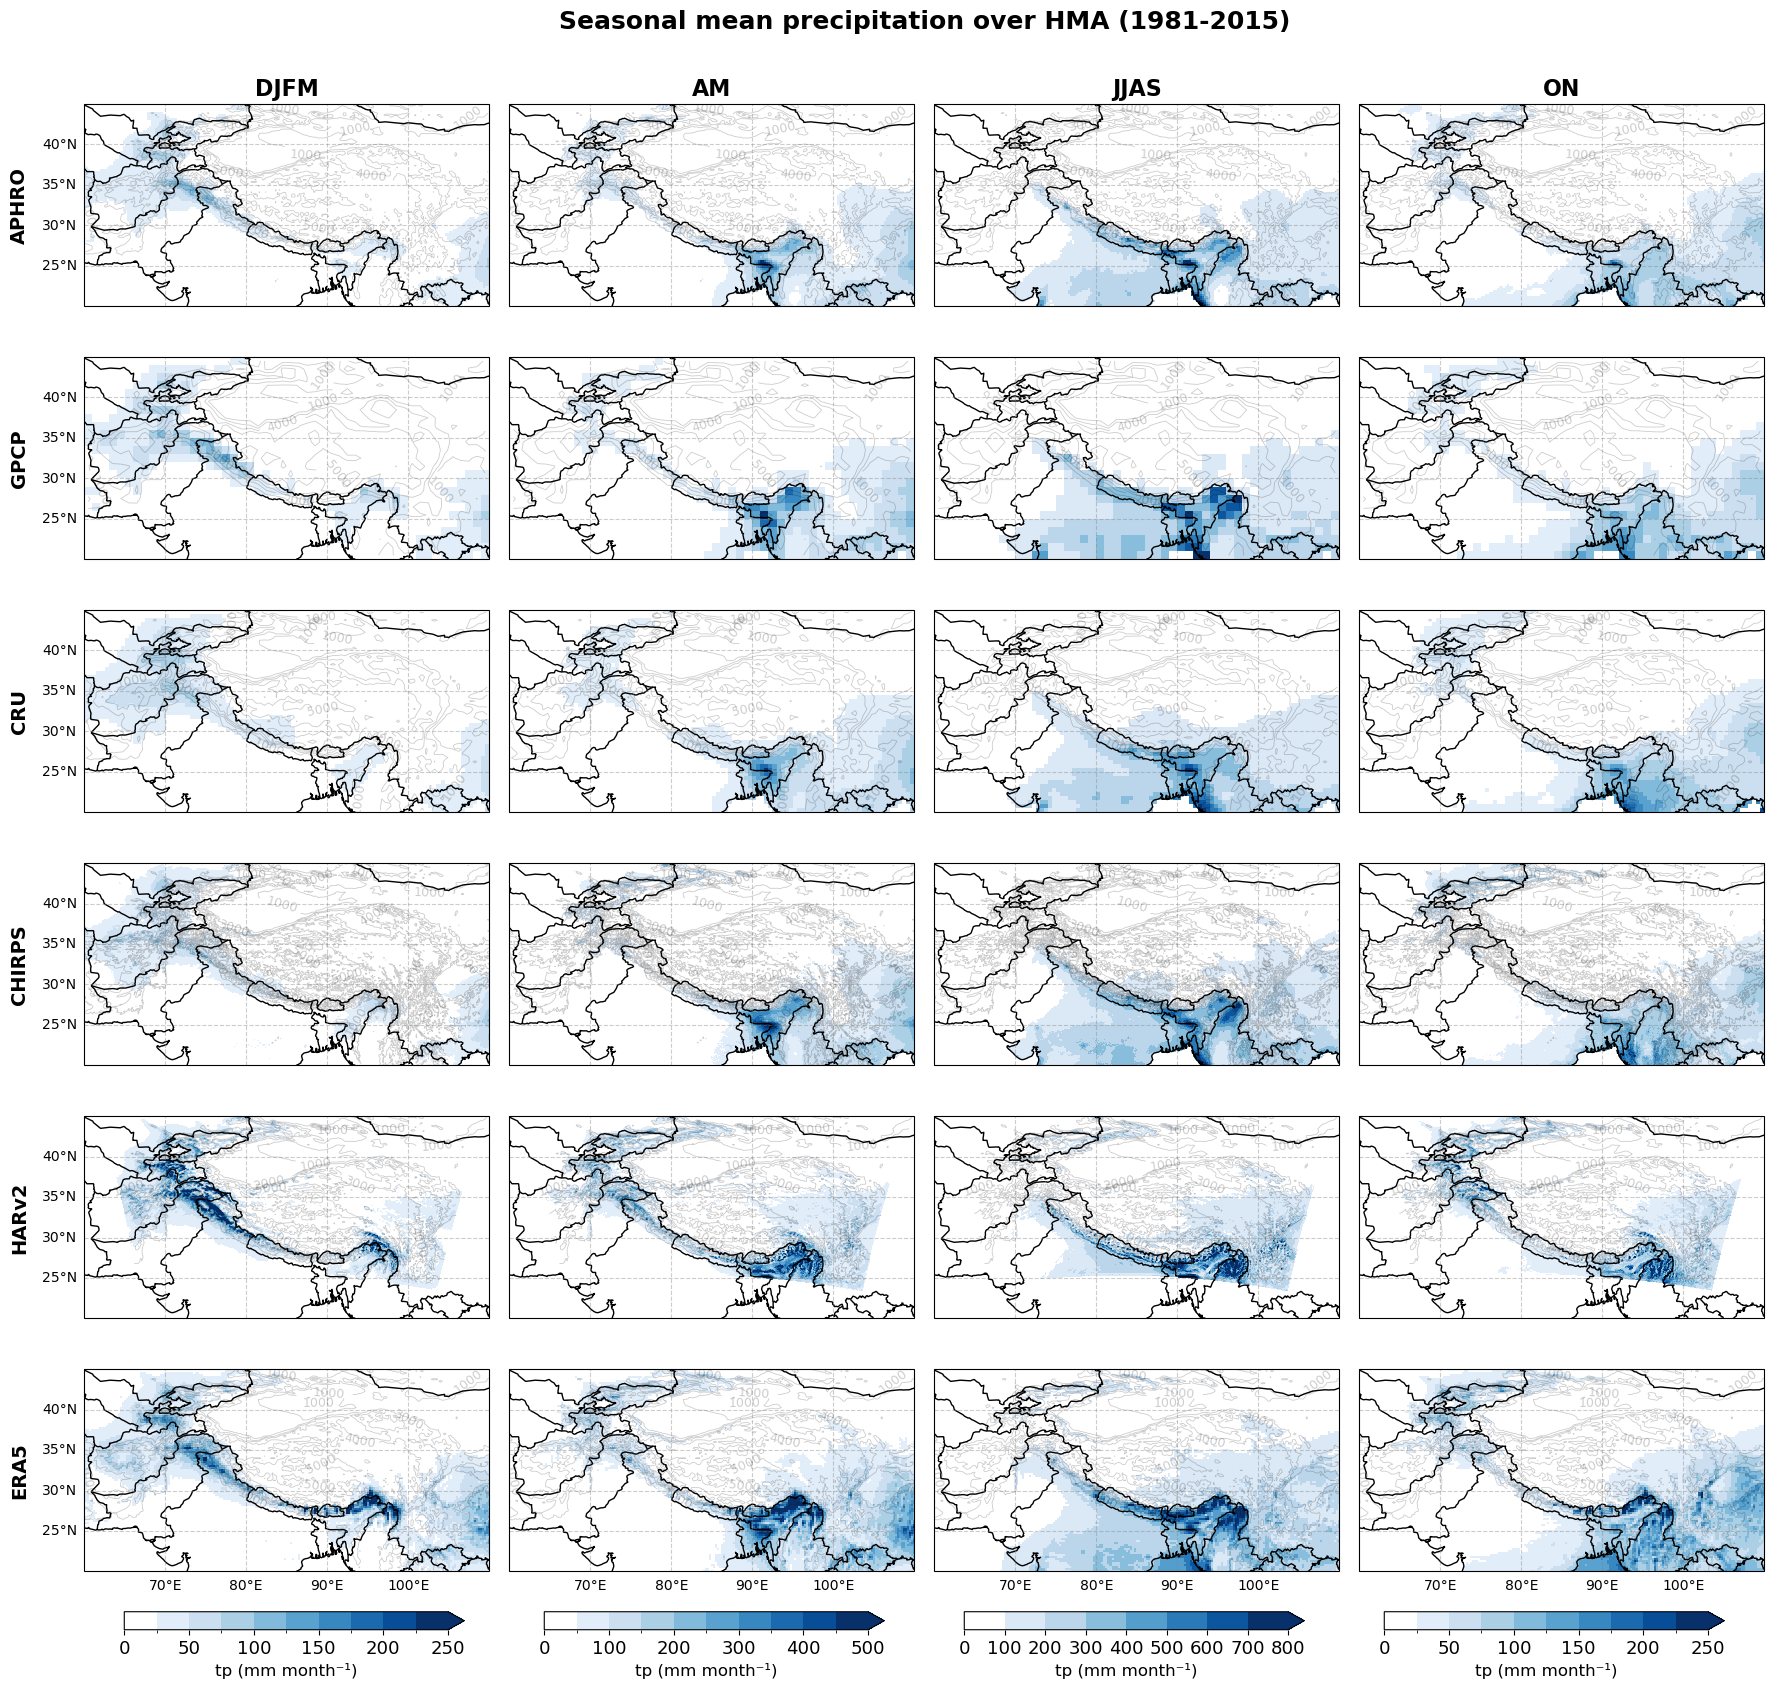

In [27]:
#==================== Color grading for each season ============================

vmax_dict = {
    "DJFM": 275,
    "AM": 550,
    "JJAS": 900,
    "ON": 275
}

step_dict = {
    "DJFM": 25,
    "AM": 50,
    "JJAS": 100,
    "ON": 25
}

cmap_dict = {}
norm_dict = {}

for season in seasons:

    vmax = vmax_dict[season]
    levels = np.arange(0, vmax, step_dict[season])
    base_cmap = plt.get_cmap("Blues", len(levels)-1)
    colors = base_cmap(np.arange(base_cmap.N))
    colors[0] = [1, 1, 1, 1]
    cmap_dict[season] = mcolors.ListedColormap(colors)
    norm_dict[season] = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each season for each dataset ==================

n_models = len(models)
n_seasons = len(seasons)
ims = [None] * n_seasons

fig, axes = plt.subplots(
    n_models, n_seasons,
    figsize=(5*n_seasons, 3*n_models),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, model in enumerate(models):
    for j, season in enumerate(seasons):

        ax = axes[i, j]
        data_model = tp_dict[model][season]

        im = ax.pcolormesh(
            data_model['lon'], data_model['lat'], data_model,
            transform=ccrs.PlateCarree(),
            cmap=cmap_dict[season],
            norm=norm_dict[season],
            shading="auto"
        )
        ims[j] = im
        
        ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle="-")

        SH = ax.contour(
            field_SH_dict[model].lon,
            field_SH_dict[model].lat,
            field_SH_dict[model],
            levels=[1000,2000,3000,4000,5000,6000,7000],
            colors="k",
            linewidths=0.6,
            alpha=0.2,
            transform=ccrs.PlateCarree()
        )
        ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

        # titres colonnes (saisons)
        if i == 0:
            ax.set_title(season, fontsize=16, weight="bold")

        # labels lignes (modèles)
        if j == 0:
            ax.text(
                -0.16, 0.5, model,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                weight="bold"
            )

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.8,
            color="gray",
            alpha=0.4,
            linestyle="--"
        )

        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (j == 0)
        gl.bottom_labels = (i == n_models-1)

        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

#==================== Bar color for each season ============================

for j, season in enumerate(seasons):

    # position horizontale selon la colonne
    left = 0.10 + j*(0.84/n_seasons)
    width = 0.84/n_seasons - 0.04

    cbar_ax = fig.add_axes([left, 0.08, width, 0.01])

    cbar = fig.colorbar(
        ims[j],
        cax=cbar_ax,
        orientation="horizontal",
        extend="max"
    )

    cbar.set_label(f"tp (mm month⁻¹)", fontsize=12)
    cbar.ax.tick_params(labelsize=13)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.11, wspace=0.05, hspace=0.20)
plt.suptitle(
    f"Seasonal mean precipitation over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Seasonal Trend datasets

In [29]:
seasons = ['DJFM', 'AM', 'JJAS', 'ON'] 

trend_dict = {}
p_dict = {}

for model in models:
    trend_dict[model] = {}
    p_dict[model] = {}
    for season in seasons:
        path = f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc'
        par = xr.open_dataset(path)

        trend = par['trend'];p = par['pvalue']
        trend_dict[model][season] = trend
        p_dict[model][season] = p

5


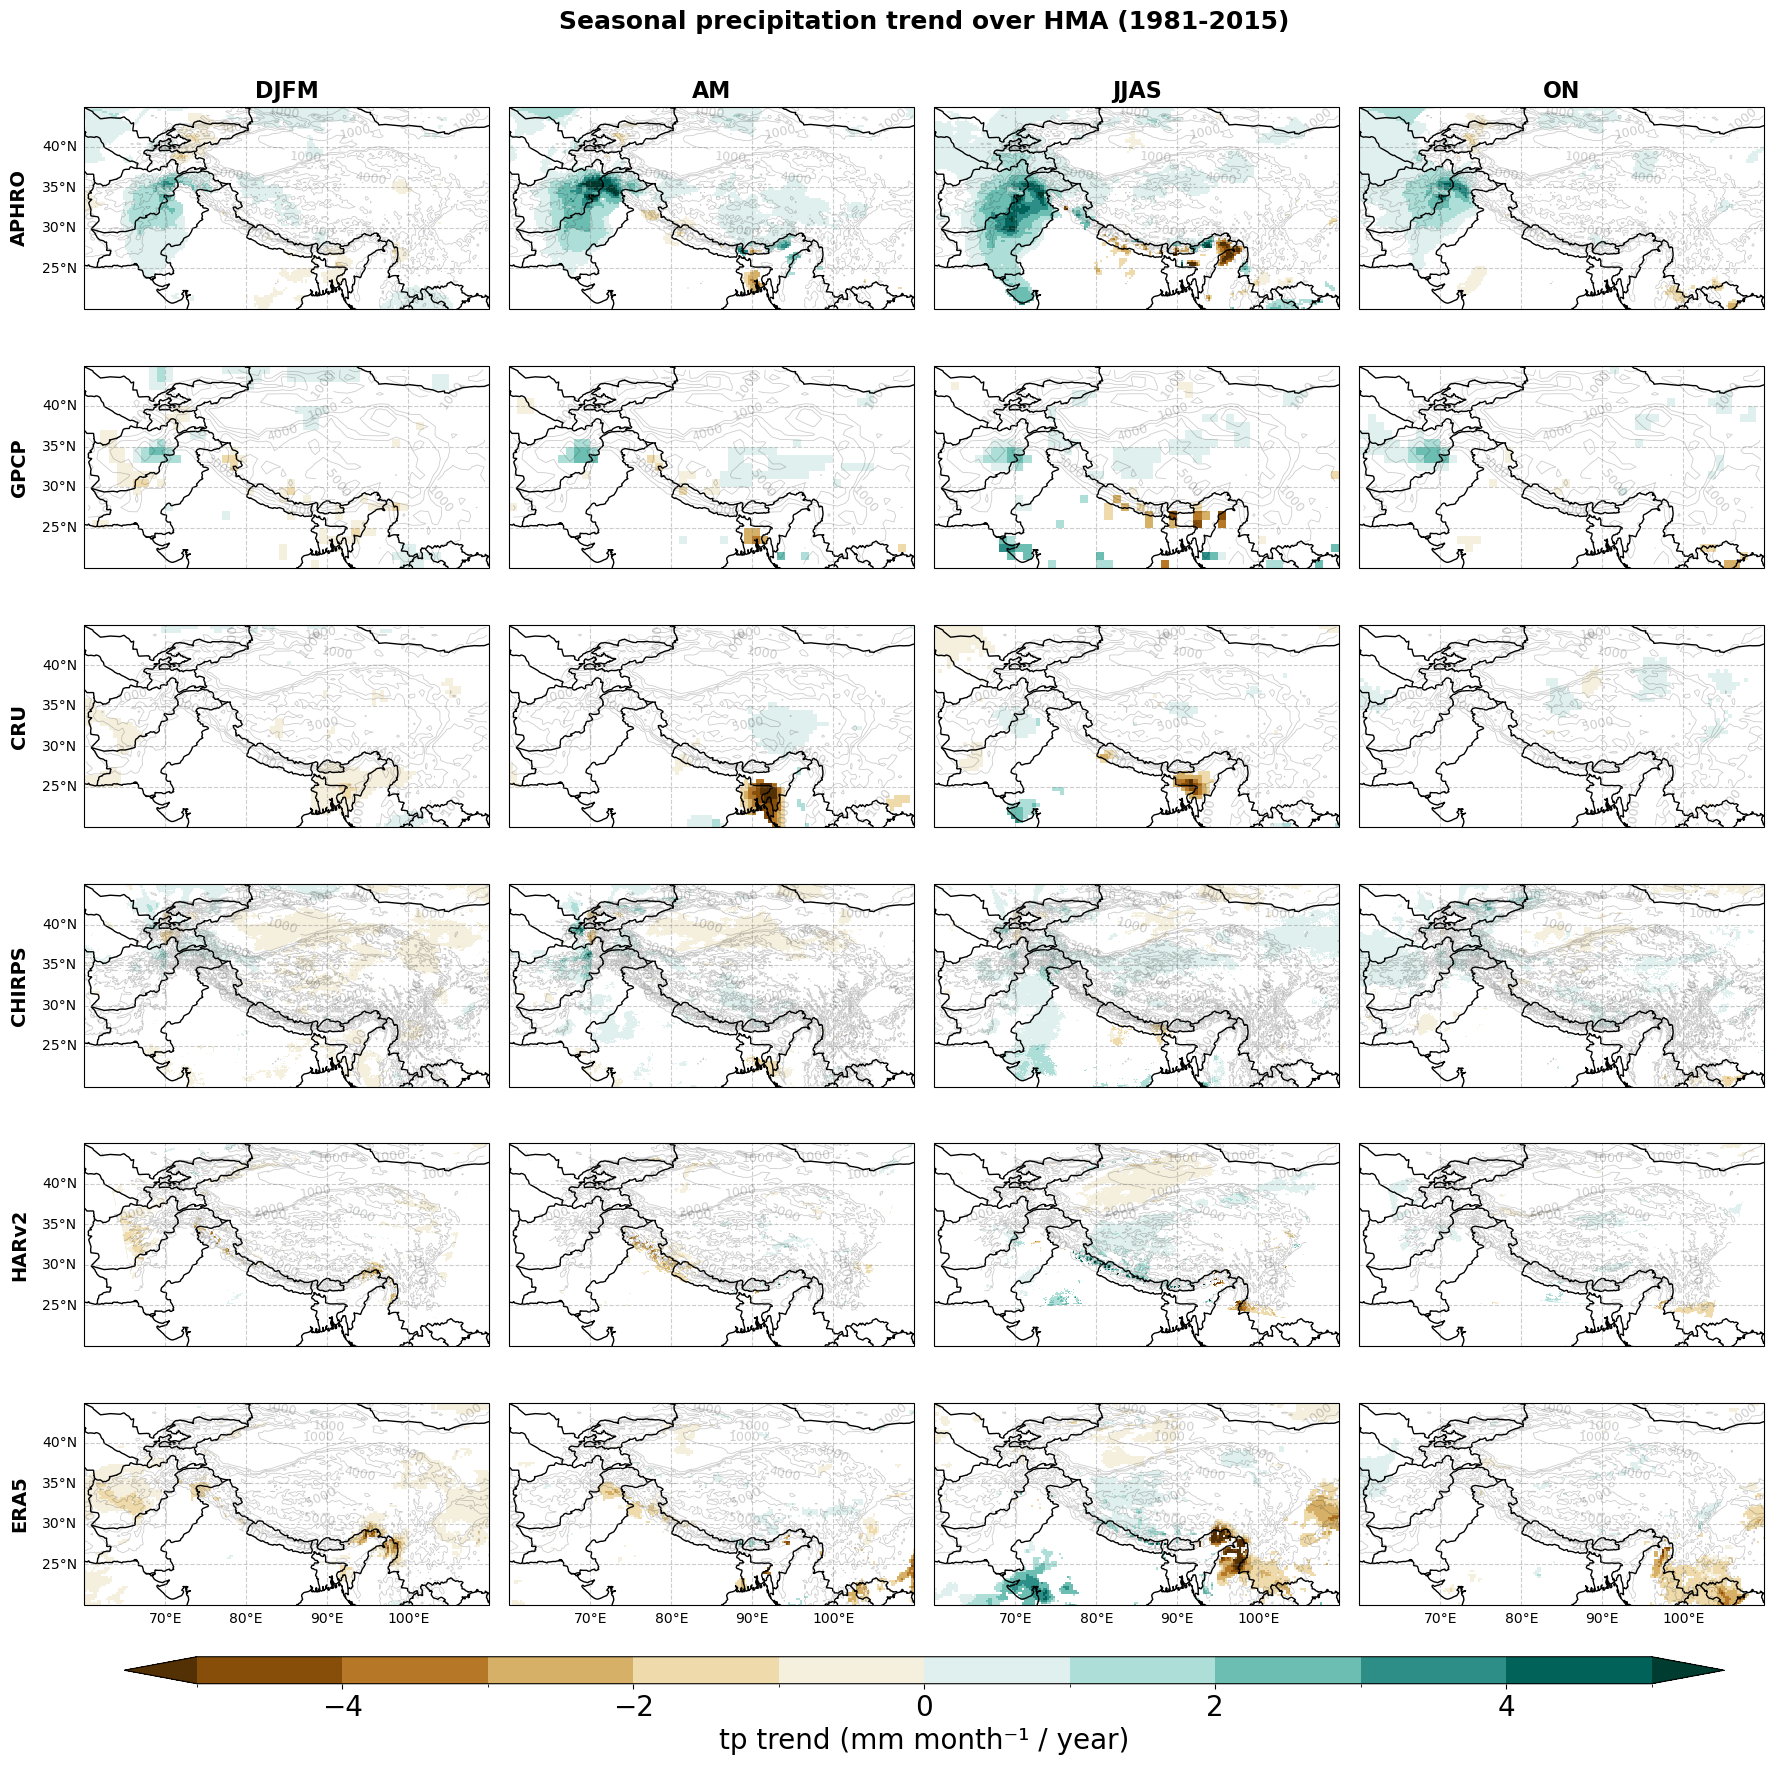

In [35]:
#==================== Color grading ============================

step = 1
vmax = 5
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season for each dataset ==================

n_models = len(models)
n_seasons = len(seasons)
ims = [None] * n_seasons

fig, axes = plt.subplots(
    n_models, n_seasons,
    figsize=(5*n_seasons, 3*n_models),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, model in enumerate(models):
    for j, season in enumerate(seasons):

        ax = axes[i, j]
        data_model = trend_dict[model][season]

        # Masque blanc pour zones non significatives
        sig = p_dict[model][season] < 0.05  # True = significatif
    
        # Crée une copie pour le plot avec NaN pour non significatif
        data_plot = data_model.where(sig)
        
        im = ax.pcolormesh(
            data_model['lon'], data_model['lat'], data_plot,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            shading="auto"
        )
        ims[j] = im
        
        ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle="-")

        SH = ax.contour(
            field_SH_dict[model].lon,
            field_SH_dict[model].lat,
            field_SH_dict[model],
            levels=[1000,2000,3000,4000,5000,6000,7000],
            colors="k",
            linewidths=0.6,
            alpha=0.2,
            transform=ccrs.PlateCarree()
        )
        ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

        # titres colonnes (saisons)
        if i == 0:
            ax.set_title(season, fontsize=16, weight="bold")

        # labels lignes (modèles)
        if j == 0:
            ax.text(
                -0.16, 0.5, model,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                weight="bold"
            )

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.8,
            color="gray",
            alpha=0.4,
            linestyle="--"
        )

        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (j == 0)
        gl.bottom_labels = (i == n_models-1)

        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.09, wspace=0.05, hspace=0.20)
plt.suptitle(
    f"Seasonal precipitation trend over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()